In [ ]:
%pip install qiskit qiskit_aer pylatexenc

In [80]:
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np

rng = np.random.default_rng(42)
simulator = AerSimulator()

# 5-Qubit Quantum Error Correction Code
The $[\![5,1,3]\!]$ code is the smallest quantum error-correcting code capable of correcting any single-qubit error. It encodes 1 logical qubit into 5 physical qubits, and the notation $$[\![n,k,d]\!] = [\![5,1,3]\!]$$ means n=5 physical qubits, k=1 logical qubit, and code distance d=3. The distance determines how many single-qubit errors the code can correct: a distance-3 code can correct any $$\left\lfloor \frac{d-1}{2}\right\rfloor = 1$$ single-qubit error. The $[\![5,1,3]\!]$ code is called *perfect* because it achieves the minimum possible n for these parameters.

The stabilizer group, $S=\langle g_1, g_2, g_3, g_4\rangle$, has $16$ elements and is generated by the following $4$ elements:
$$
\begin{align*}
g_1 &= XZZXI\\
g_2 &= IXZZX\\
g_3 &= XIXZZ\\
g_4 &= ZXIXZ
\end{align*}
$$
Each is a cyclic permutation of the other. Note that the remaining permutation, $ZZXIX$, is unnecessary since
$$
ZZXIX = P_1P_2P_3P_4,
$$
which follows from the fact that $X^2=Z^2=I$.

$\operatorname{Stab}(S)$ is the subspace of all valid, error-free states, namely the simultaneous $+1$-eigenspace of these four generators. Its elements are precisely those $|\psi\rangle$ which satisfy $P_i|\psi\rangle = |\psi\rangle$.

**Logical Operators:** 
$$
\begin{align*}
\overline{X} &= XXXXX\\
\overline{Z} &= ZZZZZ
\end{align*}
$$
These are the analogues of $X$ and $Z$ for the logical (i.e. encoded) qubit, i.e.
$$
\begin{align*}
\overline{X}|0_L\rangle &=  |1_L\rangle\\
\overline{X}|1_L\rangle &=  |0_L\rangle\\
\overline{Z}|0_L\rangle &=  |0_L\rangle\\
\overline{Z}|1_L\rangle &= -|1_L\rangle
\end{align*}
$$

## Logical codewords

The code space is the simultaneous $+1$ eigenspace of all four generators. Any basis for this two-dimensional subspace works — the standard choice is $|0_L\rangle$ and $|1_L\rangle$, the eigenstates of $\overline{Z} = ZZZZZ$ with eigenvalues $+1$ and $-1$ respectively. Both can be written as sums over the stabilizer group:

$$|0_L\rangle = \frac{1}{4} \sum_{P \in S} P\, |00000\rangle \qquad |1_L\rangle = \overline{X}\,|0_L\rangle = X^{\otimes 5}\,|0_L\rangle$$

This formula comes from the projector onto the code space. The projector onto the $+1$ eigenspace of a single stabilizer $P$ is $\frac{I+P}{2}$. Taking the product over all four generators gives the projector onto their simultaneous $+1$ eigenspace:

$$\Pi = \prod_{i=1}^{4} \frac{I + P_i}{2} = \frac{1}{16} \sum_{P \in S} P$$

Applying $\Pi$ to any reference state gives a vector in the code space. Using $|00000\rangle$ as the reference yields a state proportional to $|0_L\rangle$, and $|1_L\rangle$ follows by applying $\overline{X} = X^{\otimes 5}$.

**Normalization.** $\Pi$ is a projector, not a unitary, so it does not preserve norms. The squared norm of $\Pi|00000\rangle$ is $$\langle 00000|\Pi|00000\rangle = \frac{1}{16}\sum_{P \in S}\langle 00000|P|00000\rangle.$$ Any group element with an $X$ or $Y$ on any qubit maps $|00000\rangle$ to an orthogonal state, so its expectation value is zero. Only the identity survives, giving $\langle 00000|\Pi|00000\rangle = \frac{1}{16}$. Therefore $\|\Pi|00000\rangle\| = \frac{1}{4}$, and the normalized codeword is $$|0_L\rangle = 4\cdot\Pi|00000\rangle = \frac{1}{4}\sum_{P \in S} P|00000\rangle,$$ exactly as described in the formula above.

Each codeword is a uniform superposition of 16 computational basis states with amplitudes $\pm 1/4$. The two sets of 16 states are disjoint, which is why the codewords are orthogonal. The full stabilizer group $S$ and the explicit codeword vectors are derived below.

In [81]:
GENERATORS = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']

# ── Enumerate all 16 stabilizer group elements ───────────────────────────────
# Single-qubit Pauli multiplication table: (P, Q) → (phase, P·Q)
_MUL = {
    ('I','I'):(1,  'I'), ('I','X'):(1,  'X'), ('I','Y'):(1,   'Y'), ('I','Z'):(1,  'Z'),
    ('X','I'):(1,  'X'), ('X','X'):(1,  'I'), ('X','Y'):(1j,  'Z'), ('X','Z'):(-1j,'Y'),
    ('Y','I'):(1,  'Y'), ('Y','X'):(-1j,'Z'), ('Y','Y'):(1,   'I'), ('Y','Z'):(1j, 'X'),
    ('Z','I'):(1,  'Z'), ('Z','X'):(1j, 'Y'), ('Z','Y'):(-1j, 'X'), ('Z','Z'):(1,  'I'),
}

group = []
for subset in range(16):
    paulis, phase = list('IIIII'), 1+0j
    for i, g in enumerate(GENERATORS):
        if subset & (1 << i):
            for j in range(5):
                ph, paulis[j] = _MUL[(paulis[j], g[j])]
                phase *= ph
    assert np.isclose(phase, 1), f"Unexpected phase {phase} for subset {subset:04b}"
    group.append(''.join(paulis))

print("Stabilizer group S (16 elements):\n")
for pauli in sorted(group):
    print(pauli)

Stabilizer group S (16 elements):

IIIII
IXZZX
IYXXY
IZYYZ
XIXZZ
XXYIY
XYIYX
XZZXI
YIYXX
YXXYI
YYZIZ
YZIZY
ZIZYY
ZXIXZ
ZYYZI
ZZXIX


In [82]:
# Qiskit statevector index convention: index = q0 + 2*q1 + 4*q2 + 8*q3 + 16*q4
psi_L0 = np.zeros(32, dtype=np.complex128)
psi_L0[[0, 5, 9, 10, 18, 20]] = 1/4       # +1 terms
psi_L0[[3, 6, 12, 15, 17, 23, 24, 27, 29, 30]] = -1/4  # -1 terms

psi_L1 = np.zeros(32, dtype=np.complex128)
psi_L1[[11, 13, 21, 22, 26, 31]] = 1/4    # +1 terms
psi_L1[[1, 2, 4, 7, 8, 14, 16, 19, 25, 28]] = -1/4  # -1 terms

assert np.isclose(np.linalg.norm(psi_L0), 1.0)
assert np.isclose(np.linalg.norm(psi_L1), 1.0)
assert np.isclose(psi_L0 @ psi_L1, 0.0)
print("Codewords verified: orthonormal")

Codewords verified: orthonormal


In [83]:
# ── Derive codewords from the stabilizer group ───────────────────────────────
psi_L0_derived = np.zeros(32, dtype=complex)

for pauli_str in group:
    # Apply the product Pauli to |00000⟩.
    # X|0⟩ = |1⟩, Y|0⟩ = i|1⟩, Z|0⟩ = |0⟩, I|0⟩ = |0⟩
    # → output bit j = 1 iff Pauli at j is X or Y; Y also contributes a phase of i.
    out_index = sum(2**j for j, p in enumerate(pauli_str) if p in ('X', 'Y'))
    phase = 1j ** pauli_str.count('Y')
    psi_L0_derived[out_index] += phase / 4

# |1_L⟩ = XXXXX|0_L⟩: X on each qubit flips the corresponding bit, no phase.
# Flipping all 5 bits of an index is XOR with 11111₂ = 31.
psi_L1_derived = psi_L0_derived[np.arange(32, dtype=int) ^ 31]

print("Derived |0_L⟩ matches hardcoded:", np.allclose(psi_L0_derived, psi_L0))
print("Derived |1_L⟩ matches hardcoded:", np.allclose(psi_L1_derived, psi_L1))

Derived |0_L⟩ matches hardcoded: True
Derived |1_L⟩ matches hardcoded: True


## Building the circuit

**Syndrome extraction** measures each stabilizer generator without collapsing the encoded superposition. One ancilla qubit is used per generator, via the gadget:

$$H \;\to\; \text{controlled-}g_i \;\to\; H \;\to\; \text{measure}$$

**Why this works (phase kickback).** The ancilla starts in $|{+}\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$. After the controlled-$g_i$ step:

$$\frac{1}{\sqrt{2}}\bigl(|0\rangle \otimes |\psi\rangle \;+\; |1\rangle \otimes g_i|\psi\rangle\bigr)$$

Since $|\psi\rangle$ is an eigenstate of $g_i$ with eigenvalue $\pm 1$, this simplifies to $|{\pm}\rangle \otimes |\psi\rangle$ — the ancilla and data **factor apart completely**. The data is untouched; the eigenvalue has been encoded into the ancilla's phase. The final $H$ converts $|{+}\rangle \to |0\rangle$ and $|{-}\rangle \to |1\rangle$, giving a classical bit that reveals the eigenvalue without disclosing which superposition term the data is in.

For stabilizer Pauli $P$ at qubit $j$ (controlled on ancilla):
- $X$: `CX(ancilla, data[j])`
- $Z$: `CZ(ancilla, data[j])`
- $I$: nothing

**Syndrome Integers.** The four ancilla measurements yield a 4-bit integer $$s = s_{g_1} + 2s_{g_2} + 4s_{g_3} + 8s_{g_4}.$$ Syndrome 0 means no error. Each of the 15 possible single-qubit errors maps to a *distinct* nonzero syndrome. Consequently, this is a *perfect code*: it saturates the quantum Hamming bound, using all $2^4 - 1 = 15$ available nonzero syndromes with no waste.

**Syndrome → Correction Lookup:**

| Error | $(s_{g_1}, s_{g_2}, s_{g_3}, s_{g_4})$ | Integer |
|-------|-----------------------------------------|---------|
| X on q0 | (0,0,0,1) | 8 |
| X on q1 | (1,0,0,0) | 1 |
| X on q2 | (1,1,0,0) | 3 |
| X on q3 | (0,1,1,0) | 6 |
| X on q4 | (0,0,1,1) | 12 |
| Z on q0 | (1,0,1,0) | 5 |
| Z on q1 | (0,1,0,1) | 10 |
| Z on q2 | (0,0,1,0) | 4 |
| Z on q3 | (1,0,0,1) | 9 |
| Z on q4 | (0,1,0,0) | 2 |
| Y on q0 | (1,0,1,1) | 13 |
| Y on q1 | (1,1,0,1) | 11 |
| Y on q2 | (1,1,1,0) | 7 |
| Y on q3 | (1,1,1,1) | 15 |
| Y on q4 | (0,1,1,1) | 14 |

**Note:** Y syndromes equal the XOR of the corresponding X and Z syndromes, since $Y = iXZ$ anti-commutes with a generator precisely when that generator has $X$ or $Z$ at the relevant position — the union of the conditions for $X$ and $Z$ errors separately.

In [84]:
# ── Derive syndrome → correction lookup table ────────────────────────────────
def anticommutes(p: str, q: str) -> int:
    """1 if single-qubit Paulis p and q anti-commute, 0 otherwise.
    Two non-identity Paulis anti-commute iff they are distinct."""
    return int(p != 'I' and q != 'I' and p != q)

# Build and display the full table
correction_table = {}
print(f"{'Error':<10} {'(s_g1, s_g2, s_g3, s_g4)':<26} {'Integer':>7}")
print("─" * 46)
for pauli in ['X', 'Z', 'Y']:
    for qubit in range(5):
        bits = [anticommutes(g[qubit], pauli) for g in GENERATORS]
        sint = sum(b << i for i, b in enumerate(bits))
        correction_table[sint] = (pauli, qubit)
        print(f"{pauli} on q{qubit}    ({', '.join(str(b) for b in bits)}){'':>10} {sint:>7}")

# All 15 non-zero syndromes must be unique for the code to be "perfect"
assert len(correction_table) == 15, "Syndrome collision — not a perfect code!"
print(f"\nAll 15 syndromes are unique: code saturates the quantum Hamming bound.")

# Cross-check against the switch statement in build_circuit
hardcoded = {
     8: ('X', 0),  1: ('X', 1),  3: ('X', 2),  6: ('X', 3), 12: ('X', 4),
     5: ('Z', 0), 10: ('Z', 1),  4: ('Z', 2),  9: ('Z', 3),  2: ('Z', 4),
    13: ('Y', 0), 11: ('Y', 1),  7: ('Y', 2), 15: ('Y', 3), 14: ('Y', 4),
}
assert correction_table == hardcoded, "Mismatch with hardcoded switch statement!"
print("Derived table matches the switch statement in build_circuit.")

Error      (s_g1, s_g2, s_g3, s_g4)   Integer
──────────────────────────────────────────────
X on q0    (0, 0, 0, 1)                 8
X on q1    (1, 0, 0, 0)                 1
X on q2    (1, 1, 0, 0)                 3
X on q3    (0, 1, 1, 0)                 6
X on q4    (0, 0, 1, 1)                12
Z on q0    (1, 0, 1, 0)                 5
Z on q1    (0, 1, 0, 1)                10
Z on q2    (0, 0, 1, 0)                 4
Z on q3    (1, 0, 0, 1)                 9
Z on q4    (0, 1, 0, 0)                 2
Y on q0    (1, 0, 1, 1)                13
Y on q1    (1, 1, 0, 1)                11
Y on q2    (1, 1, 1, 0)                 7
Y on q3    (1, 1, 1, 1)                15
Y on q4    (0, 1, 1, 1)                14

All 15 syndromes are unique: code saturates the quantum Hamming bound.
Derived table matches the switch statement in build_circuit.


In [ ]:
def _add_syndrome_extraction(qc, data, ancillas):
    """Add syndrome extraction and classical feedforward correction to qc."""
    # g1 = X Z Z X I
    qc.h(ancillas[0])
    qc.cx(ancillas[0], data[0])
    qc.cz(ancillas[0], data[1])
    qc.cz(ancillas[0], data[2])
    qc.cx(ancillas[0], data[3])
    qc.h(ancillas[0])
    qc.barrier()

    # g2 = I X Z Z X
    qc.h(ancillas[1])
    qc.cx(ancillas[1], data[1])
    qc.cz(ancillas[1], data[2])
    qc.cz(ancillas[1], data[3])
    qc.cx(ancillas[1], data[4])
    qc.h(ancillas[1])
    qc.barrier()

    # g3 = X I X Z Z
    qc.h(ancillas[2])
    qc.cx(ancillas[2], data[0])
    qc.cx(ancillas[2], data[2])
    qc.cz(ancillas[2], data[3])
    qc.cz(ancillas[2], data[4])
    qc.h(ancillas[2])
    qc.barrier()

    # g4 = Z X I X Z
    qc.h(ancillas[3])
    qc.cz(ancillas[3], data[0])
    qc.cx(ancillas[3], data[1])
    qc.cx(ancillas[3], data[3])
    qc.cz(ancillas[3], data[4])
    qc.h(ancillas[3])
    qc.barrier()

    # ── Measure syndromes ─────────────────────────────────────────────────────
    # syndromes[i] = ancilla for g_{i+1}
    # integer value = s_g1·1 + s_g2·2 + s_g3·4 + s_g4·8
    syndromes = ClassicalRegister(4, "s")
    qc.add_register(syndromes)
    qc.measure(ancillas, syndromes)
    qc.barrier()

    # ── Correction ───────────────────────────────────────────────────────────
    with qc.switch(syndromes) as case:
        with case(0):   pass             # no error
        with case(8):   qc.x(data[0])    # X on q0
        with case(1):   qc.x(data[1])    # X on q1
        with case(3):   qc.x(data[2])    # X on q2
        with case(6):   qc.x(data[3])    # X on q3
        with case(12):  qc.x(data[4])    # X on q4
        with case(5):   qc.z(data[0])    # Z on q0
        with case(10):  qc.z(data[1])    # Z on q1
        with case(4):   qc.z(data[2])    # Z on q2
        with case(9):   qc.z(data[3])    # Z on q3
        with case(2):   qc.z(data[4])    # Z on q4
        with case(13):  qc.y(data[0])    # Y on q0
        with case(11):  qc.y(data[1])    # Y on q1
        with case(7):   qc.y(data[2])    # Y on q2
        with case(15):  qc.y(data[3])    # Y on q3
        with case(14):  qc.y(data[4])    # Y on q4


def build_circuit(x: int = 0, error_qubit: int | None = None, error_type: str | None = None) -> QuantumCircuit:
    """
    Build the [[5,1,3]] QEC circuit.
    x:           logical state to encode (0 → |0_L⟩, 1 → |1_L⟩)
    error_qubit: 0–4, or None for no error
    error_type:  'X', 'Y', or 'Z'
    """
    data = QuantumRegister(5, "q")
    ancillas = AncillaRegister(4, "anc")
    qc = QuantumCircuit(data, ancillas, name="[[5,1,3]] code")

    # ── Initialize logical state ──────────────────────────────────────────────
    qc.initialize(psi_L0 if x == 0 else psi_L1, data)
    qc.barrier()

    # ── Inject single-qubit X, Y, or Z error ─────────────────────────────────
    if error_qubit is not None:
        if error_type == "X":
            qc.x(data[error_qubit])
        elif error_type == "Y":
            qc.y(data[error_qubit])
        elif error_type == "Z":
            qc.z(data[error_qubit])
    qc.barrier()

    _add_syndrome_extraction(qc, data, ancillas)
    return qc

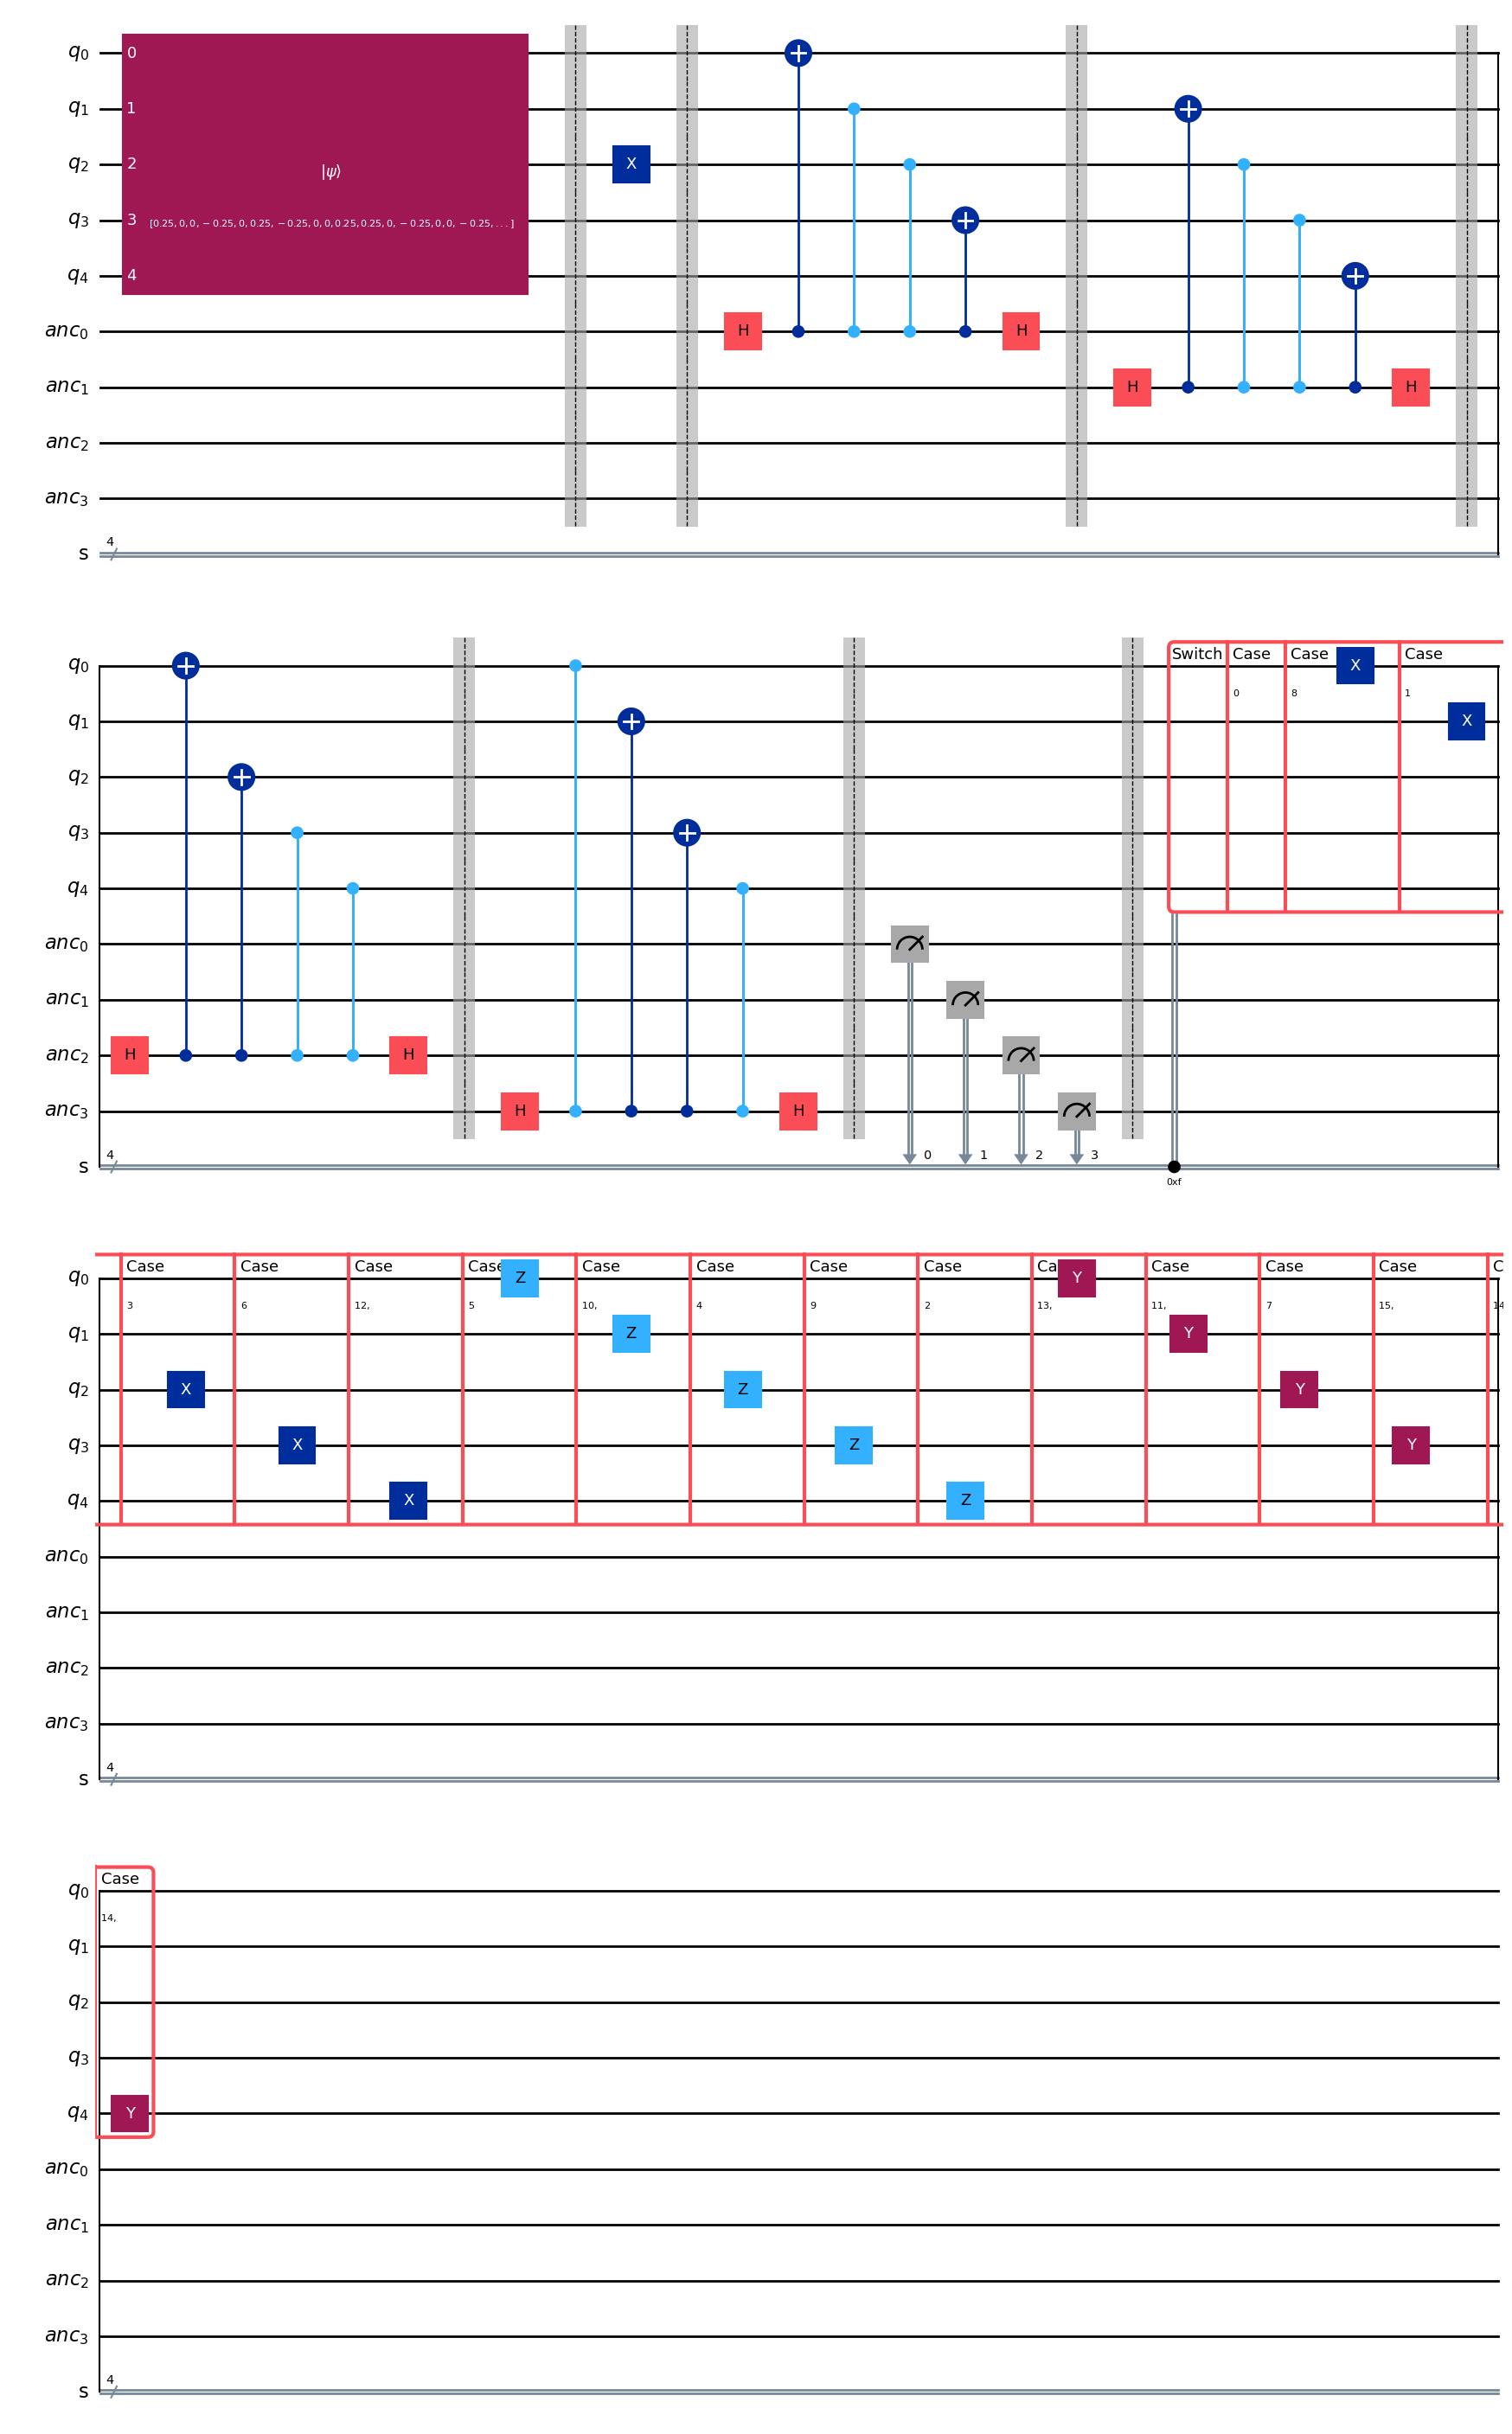

In [86]:
build_circuit(x=0, error_qubit=2, error_type="X").draw(output="mpl")

## Verification

We verify correctness in two stages.

**Stage 1 — Code-space membership.** After error injection and correction, measuring the data qubits should always yield one of the 16 basis states belonging to either $|0_L\rangle$ or $|1_L\rangle$. A result outside these sets would indicate the circuit failed to return the state to the code space entirely.

**Stage 2 — Logical value preservation.** The measurement must land in the *correct* logical state's set — an error on $|0_L\rangle$ should still yield a $|0_L\rangle$ basis state after correction, not a $|1_L\rangle$ one.

One implementation note: the syndrome register retains the pre-correction measurement result. In Qiskit's output format, keys look like `"data_bits syndrome_bits"` — the syndrome half records the evidence of the error even after the data has been fixed. This is expected.

In [87]:
# Build sets of valid measurement strings for each logical state.
# Qiskit displays the register as a bit string with qubit 4 on the left (MSB first),
# so the string for index i is format(i, '05b').
zero_L_states = {format(i, '05b') for i in range(32) if not np.isclose(psi_L0[i], 0)}
one_L_states  = {format(i, '05b') for i in range(32) if not np.isclose(psi_L1[i], 0)}

assert len(zero_L_states) == 16 and len(one_L_states) == 16
assert zero_L_states.isdisjoint(one_L_states)
print("Code-space state sets verified")

Code-space state sets verified


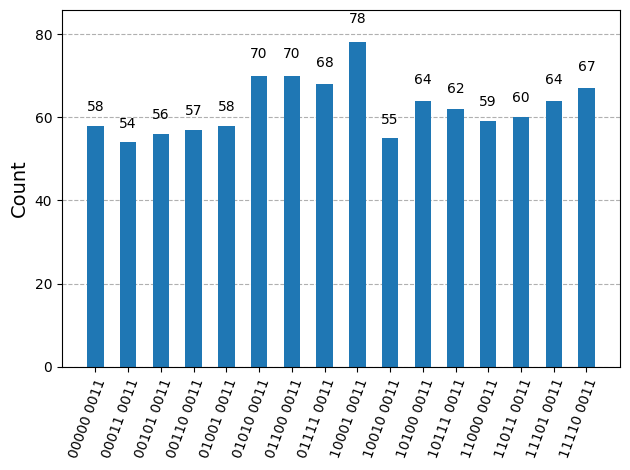

In [88]:
def run_trial(x: int, error_qubit: int | None, error_type: str | None, shots: int = 1000) -> dict:
    qc = build_circuit(x, error_qubit, error_type)

    data_measurements = ClassicalRegister(5, "data")
    qc.add_register(data_measurements)
    qc.measure(qc.qregs[0], data_measurements)  # measure data register

    compiled = transpile(qc, simulator)
    return simulator.run(compiled, shots=shots).result().get_counts()


# Test X error on qubit 2, encoding |0_L⟩
counts = run_trial(x=0, error_qubit=2, error_type="X", shots=1000)
plot_histogram(counts)

In [89]:
# After correcting an X error on q2, encoding |0_L⟩, every shot should land in zero_L_states.
# key format: "data_bits syndrome_bits" — last-added register appears first.
all_in_zero_L = all(key.split()[0] in zero_L_states for key in counts)
print(f"All measurements in |0_L⟩ basis states after X error on q2: {all_in_zero_L}")

All measurements in |0_L⟩ basis states after X error on q2: True


## Check every single-qubit X, Y, and Z error

The code claims to correct *any* single-qubit Pauli error. The batch below tests this exhaustively: both logical states ($|0_L\rangle$ and $|1_L\rangle$), all 5 physical qubits, and all 3 error types — 30 circuits in total.

Each circuit is run for 500 shots. A success rate of 1.000 confirms two things simultaneously:

1. **Code-space recovery** — after syndrome measurement and correction, every shot lands on a basis state belonging to the code space (no leakage to invalid states).
2. **Logical value preservation** — the correction returns the state to the *correct* logical state; an error on $|0_L\rangle$ does not accidentally produce $|1_L\rangle$.

A single failure in any of the 30 cases would indicate either a wrong syndrome in the lookup table or an incorrect correction gate.

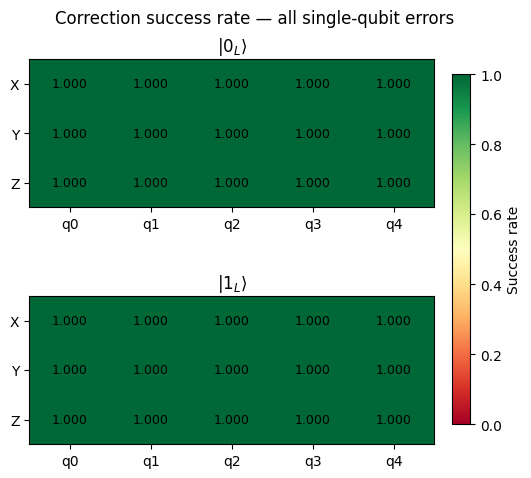

In [90]:
valid_states = {0: zero_L_states, 1: one_L_states}

def logical_success(key: str, x: int) -> bool:
    """True if the measured data matches the expected logical state x."""
    return key.split()[0] in valid_states[x]


# Build all 30 circuits, transpile and run in one batch
error_types = ["X", "Y", "Z"]
configs = [(x, qubit, err) for x in [0, 1] for qubit in range(5) for err in error_types]
circuits = []
for x, qubit, err in configs:
    qc = build_circuit(x, qubit, err)
    data_measurements = ClassicalRegister(5, "data")
    qc.add_register(data_measurements)
    qc.measure(qc.qregs[0], data_measurements)
    circuits.append(qc)

compiled = transpile(circuits, simulator)
batch_result = simulator.run(compiled, shots=500).result()

# Collect results into a (2, 3, 5) array: [logical_state, error_type, qubit]
results = np.zeros((2, 3, 5))
for i, (x, qubit, err) in enumerate(configs):
    counts  = batch_result.get_counts(i)
    success = sum(v for k, v in counts.items() if logical_success(k, x))
    results[x, error_types.index(err), qubit] = success / sum(counts.values())

# Display as a heatmap
fig, axes = plt.subplots(2, 1, figsize=(6, 5))
fig.subplots_adjust(right=0.80, hspace=0.6)
cbar_ax = fig.add_axes([0.83, 0.15, 0.03, 0.70])

for ax, x, title in zip(axes, [0, 1], [r"$|0_L\rangle$", r"$|1_L\rangle$"]):
    im = ax.imshow(results[x], vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(5));      ax.set_xticklabels([f"q{i}" for i in range(5)])
    ax.set_yticks(range(3));      ax.set_yticklabels(error_types)
    ax.set_title(title)
    for r in range(3):
        for c in range(5):
            ax.text(c, r, f"{results[x, r, c]:.3f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, cax=cbar_ax, label="Success rate")
fig.suptitle("Correction success rate — all single-qubit errors")
plt.show()

## Success rate under random Pauli noise

The exhaustive test above only injects exactly one error at a known location. In practice, errors occur randomly and independently on each qubit. The simulation here models **depolarizing noise**: each of the 5 physical qubits receives a random Pauli error with probability $p$. When an error does occur it is equally likely to be X, Y, or Z (probability $p/3$ each).

For each value of $p$ in a sweep from 0 to 0.30, we run 512 independent trials and measure the fraction that recover the correct logical state.

**Two baseline curves** provide context:

- **Uncoded** ($1 - p$): the probability a single unprotected qubit survives without error. This is the baseline the code must beat to be worthwhile.
- **P(≤1 error)**: $(1-p)^5 + 5p(1-p)^4$, the probability that zero or one error occurs across all 5 physical qubits. At small $p$, roughly zero or one errors occur per trial, so the simulated curve tracks close to this bound. The simulated curve lies *above* it because the code can also silently correct certain 2-qubit error patterns — either their product is a stabilizer element (syndrome 0, no correction needed) or the applied correction happens to compose with the two errors to give a stabilizer.

**Behavior at high noise.** As $p$ increases, the entropy of the physical qubits increases. In the limit of fully depolarizing noise, the encoded state approaches a maximally mixed state over the code space — the two logical codewords become statistically indistinguishable — and the success rate converges toward 50%. An unprotected qubit under the same noise approaches 0% success, so the code continues to outperform the uncoded baseline across the entire range. The theoretical lower bound P(≤1 error) crosses the uncoded baseline around $p \approx 0.14$, but the actual simulated curve stays above throughout.

In [43]:
def build_circuit_random_error(x: int, p: float) -> QuantumCircuit:
    """Build circuit encoding |x_L⟩ with independent depolarizing (X/Y/Z) noise at rate p on each qubit."""
    data     = QuantumRegister(5, "q")
    ancillas = AncillaRegister(4, "anc")
    qc = QuantumCircuit(data, ancillas, name="[[5,1,3]] code")

    qc.initialize(psi_L0 if x == 0 else psi_L1, data)
    qc.barrier()

    for i in range(5):
        if rng.random() < p:
            r = rng.random()
            if r < 1/3:
                qc.x(data[i])
            elif r < 2/3:
                qc.y(data[i])
            else:
                qc.z(data[i])
    qc.barrier()

    _add_syndrome_extraction(qc, data, ancillas)
    return qc


def success_rate(p: float, x: int = 0, trials: int = 512) -> float:
    """Fraction of trials where the logical state x is preserved under noise rate p."""
    circuits = []
    for _ in range(trials):
        qc = build_circuit_random_error(x, p)
        data_measurements = ClassicalRegister(5, "data")
        qc.add_register(data_measurements)
        qc.measure(qc.qregs[0], data_measurements)
        circuits.append(qc)

    compiled = transpile(circuits, simulator)
    result   = simulator.run(compiled, shots=1).result()

    successes = sum(
        logical_success(next(iter(result.get_counts(i))), x)
        for i in range(trials)
    )
    return successes / trials

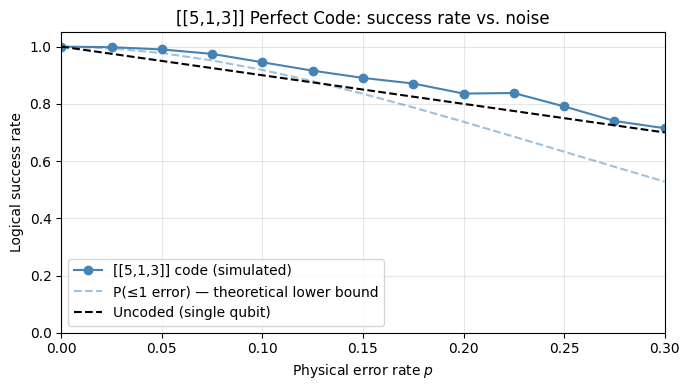

In [44]:
p_values = np.linspace(0.0, 0.30, 13)   # 0.00, 0.025, 0.05, ..., 0.30

rates = [success_rate(p, x=0, trials=512) for p in p_values]

# Theoretical baselines
uncoded    = 1 - p_values                                   # single unprotected qubit
p_01_lower = (1 - p_values)**5 + 5*p_values*(1 - p_values)**4  # P(0 errors) + P(1 error)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_values, rates,      "o-",  label="[[5,1,3]] code (simulated)", color="steelblue")
ax.plot(p_values, p_01_lower, "--",  label="P(≤1 error) — theoretical lower bound", color="steelblue", alpha=0.5)
ax.plot(p_values, uncoded,    "k--", label="Uncoded (single qubit)")

ax.set_xlabel("Physical error rate $p$")
ax.set_ylabel("Logical success rate")
ax.set_title("[[5,1,3]] Perfect Code: success rate vs. noise")
ax.legend()
ax.set_xlim(0, 0.30)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

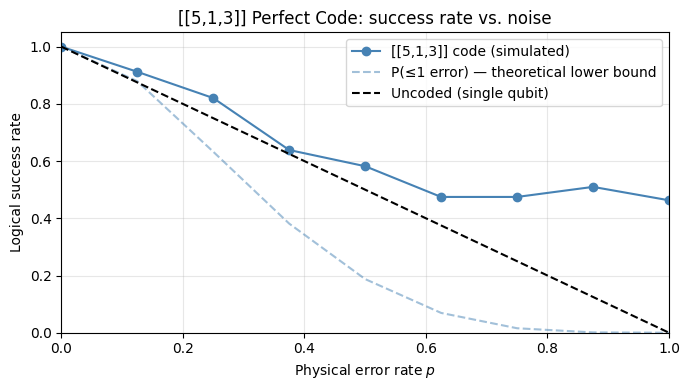

In [46]:
p_values = np.linspace(0.0, 1, 9)   # 0.00, 0.025, 0.05, ..., 0.30

rates = [success_rate(p, x=0, trials=512) for p in p_values]

# Theoretical baselines
uncoded    = 1 - p_values                                   # single unprotected qubit
p_01_lower = (1 - p_values)**5 + 5*p_values*(1 - p_values)**4  # P(0 errors) + P(1 error)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_values, rates,      "o-",  label="[[5,1,3]] code (simulated)", color="steelblue")
ax.plot(p_values, p_01_lower, "--",  label="P(≤1 error) — theoretical lower bound", color="steelblue", alpha=0.5)
ax.plot(p_values, uncoded,    "k--", label="Uncoded (single qubit)")

ax.set_xlabel("Physical error rate $p$")
ax.set_ylabel("Logical success rate")
ax.set_title("[[5,1,3]] Perfect Code: success rate vs. noise")
ax.legend()
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()